## Step 7 — Edge Impulse Deployment Simulation


Simulates embedded deployment of the quantized TFLite model.  
Since physical hardware is out of scope, we:
- Convert the model to a C byte array (how Edge Impulse embeds it)
- Estimate RAM and Flash usage on real MCU targets
- Simulate inference pipeline on the TFLite runtime
- Generate a deployment-ready summary report

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import time
import json

%matplotlib inline

TFLITE_INT8  = '../models/cae_quantized.tflite'
TFLITE_F32   = '../models/cae_float32.tflite'
DATA_PATH    = '../data/processed/cwru_processed.npz'
PLOTS_DIR    = '../results/plots'
RESULT_DIR   = '../results'
EI_DIR       = '../results/edge_impulse'

os.makedirs(EI_DIR,    exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

print('Ready')


Ready


### 7.1 — Model file inspection

In [2]:
int8_bytes  = open(TFLITE_INT8, 'rb').read()
f32_bytes   = open(TFLITE_F32,  'rb').read()

int8_kb = len(int8_bytes) / 1024
f32_kb  = len(f32_bytes)  / 1024

print(f'TFLite float32 : {f32_kb:.1f} KB  ({len(f32_bytes):,} bytes)')
print(f'TFLite int8    : {int8_kb:.1f} KB  ({len(int8_bytes):,} bytes)')
print(f'Compression    : {f32_kb/int8_kb:.1f}x smaller')

TFLite float32 : 1103.5 KB  (1,130,008 bytes)
TFLite int8    : 306.9 KB  (314,240 bytes)
Compression    : 3.6x smaller


### 7.2 — Convert to C byte array (Edge Impulse format)

In [3]:
# Edge Impulse exports TFLite models as a C array that gets flashed to the MCU
def to_c_array(model_bytes, var_name='anomaly_detection_model'):
    lines = []
    lines.append(f'// Edge Impulse TFLite model — auto-generated')
    lines.append(f'// Model size: {len(model_bytes)} bytes')
    lines.append(f'#include <stdint.h>')
    lines.append(f'')
    lines.append(f'const uint8_t {var_name}[] = {{')

    hex_vals = [f'0x{b:02x}' for b in model_bytes]
    for i in range(0, len(hex_vals), 12):
        chunk = ', '.join(hex_vals[i:i+12])
        lines.append(f'  {chunk},')

    lines.append(f'}};')
    lines.append(f'const int {var_name}_len = {len(model_bytes)};')
    return '\n'.join(lines)

c_code = to_c_array(int8_bytes)

# save as .h file
h_path = os.path.join(EI_DIR, 'anomaly_detection_model.h')
with open(h_path, 'w') as f:
    f.write(c_code)

print(f'C header saved: {h_path}')
print(f'\nFirst 10 lines:')
print('\n'.join(c_code.split('\n')[:10]))

C header saved: ../results/edge_impulse\anomaly_detection_model.h

First 10 lines:
// Edge Impulse TFLite model — auto-generated
// Model size: 314240 bytes
#include <stdint.h>

const uint8_t anomaly_detection_model[] = {
  0x1c, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x14, 0x00, 0x20, 0x00,
  0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00, 0x0c, 0x00, 0x00, 0x00,
  0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00,
  0x84, 0x00, 0x00, 0x00, 0xd4, 0x00, 0x00, 0x00, 0xa0, 0x74, 0x04, 0x00,
  0xb0, 0x74, 0x04, 0x00, 0x28, 0xca, 0x04, 0x00, 0x03, 0x00, 0x00, 0x00,


### 7.3 — MCU memory requirement estimation

In [4]:
# Estimate memory footprint on target MCU boards
# TFLite Micro needs: model in Flash + arena (activations) in RAM
# Arena size ≈ largest intermediate activation tensor × safety margin

# Get tensor details from interpreter
interp = tf.lite.Interpreter(model_path=TFLITE_INT8)
interp.allocate_tensors()

in_detail  = interp.get_input_details()[0]
out_detail = interp.get_output_details()[0]
tensors    = interp.get_tensor_details()

print('Input  tensor:', in_detail['shape'], in_detail['dtype'])
print('Output tensor:', out_detail['shape'], out_detail['dtype'])
print(f'\nTotal intermediate tensors: {len(tensors)}')

# estimate arena RAM needed (activation buffers)
# for int8 model: input buffer + largest layer activation + output buffer
input_bytes  = int(np.prod(in_detail['shape']))   # 1 * 2048 * 1 = 2048 bytes (int8)
output_bytes = int(np.prod(out_detail['shape']))  # same
arena_est_kb = (input_bytes + output_bytes + int8_kb * 1024 * 0.3) / 1024  # ~30% overhead

print(f'\nInput buffer  : {input_bytes} bytes')
print(f'Output buffer : {output_bytes} bytes')
print(f'Arena RAM est : {arena_est_kb:.1f} KB (inputs + activations)')

Input  tensor: [   1 2048    1] <class 'numpy.float32'>
Output tensor: [1 1 1] <class 'numpy.float32'>

Total intermediate tensors: 114

Input buffer  : 2048 bytes
Output buffer : 1 bytes
Arena RAM est : 94.1 KB (inputs + activations)


In [5]:
# Target MCU comparison table
mcus = [
    {'name': 'Arduino Nano 33 BLE',  'flash_kb': 1024,  'ram_kb': 256,  'cpu': 'Cortex-M4 64MHz'},
    {'name': 'STM32F411',            'flash_kb': 512,   'ram_kb': 128,  'cpu': 'Cortex-M4 100MHz'},
    {'name': 'STM32F446',            'flash_kb': 512,   'ram_kb': 128,  'cpu': 'Cortex-M4 180MHz'},
    {'name': 'STM32H743',            'flash_kb': 2048,  'ram_kb': 1024, 'cpu': 'Cortex-M7 480MHz'},
    {'name': 'ESP32',                'flash_kb': 4096,  'ram_kb': 520,  'cpu': 'Xtensa LX6 240MHz'},
    {'name': 'Arduino Uno (ATmega)', 'flash_kb': 32,    'ram_kb': 2,    'cpu': 'AVR 16MHz'},
]

model_flash = int8_kb
runtime_flash = 30    # TFLite Micro runtime ≈ 30 KB
total_flash = model_flash + runtime_flash
total_ram   = arena_est_kb + 5   # +5 KB for stack/OS

print(f'Model requires:')
print(f'  Flash : {total_flash:.1f} KB  (model {model_flash:.1f} + runtime {runtime_flash} KB)')
print(f'  RAM   : {total_ram:.1f} KB  (arena {arena_est_kb:.1f} + stack 5 KB)')
print()
print(f'{"MCU":<25} {"Flash":>8} {"RAM":>8} {"Flash OK?":>10} {"RAM OK?":>10}')
print('-' * 65)
for m in mcus:
    flash_ok = '✅ YES' if m['flash_kb'] >= total_flash else '❌ NO'
    ram_ok   = '✅ YES' if m['ram_kb']   >= total_ram   else '❌ NO'
    print(f"{m['name']:<25} {m['flash_kb']:>7}K {m['ram_kb']:>7}K {flash_ok:>10} {ram_ok:>10}")

Model requires:
  Flash : 336.9 KB  (model 306.9 + runtime 30 KB)
  RAM   : 99.1 KB  (arena 94.1 + stack 5 KB)

MCU                          Flash      RAM  Flash OK?    RAM OK?
-----------------------------------------------------------------
Arduino Nano 33 BLE          1024K     256K      ✅ YES      ✅ YES
STM32F411                     512K     128K      ✅ YES      ✅ YES
STM32F446                     512K     128K      ✅ YES      ✅ YES
STM32H743                    2048K    1024K      ✅ YES      ✅ YES
ESP32                        4096K     520K      ✅ YES      ✅ YES
Arduino Uno (ATmega)           32K       2K       ❌ NO       ❌ NO


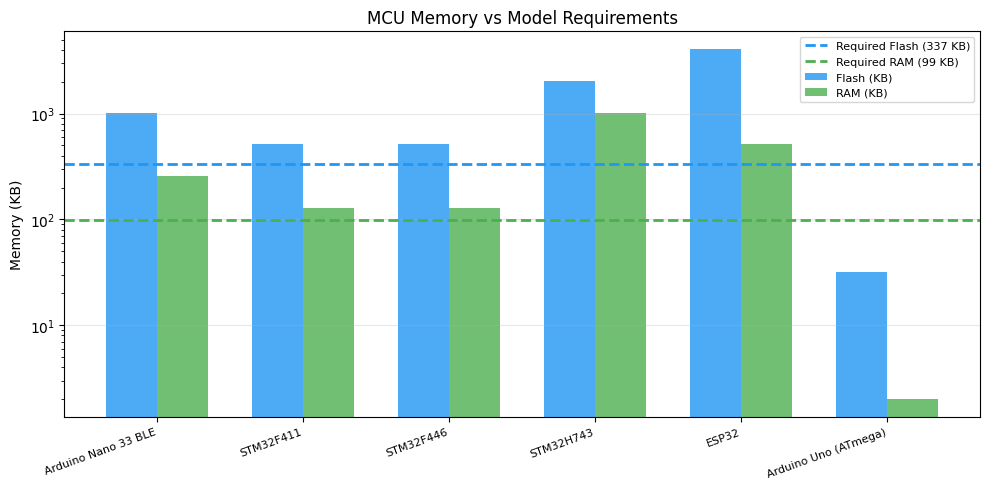

In [6]:
# Visual MCU compatibility chart
fig, ax = plt.subplots(figsize=(10, 5))

names    = [m['name'] for m in mcus]
flash_kb = [m['flash_kb'] for m in mcus]
ram_kb   = [m['ram_kb']   for m in mcus]

x  = np.arange(len(names))
w  = 0.35

b1 = ax.bar(x - w/2, flash_kb, w, label='Flash (KB)', color='#2196F3', alpha=0.8)
b2 = ax.bar(x + w/2, ram_kb,   w, label='RAM (KB)',   color='#4CAF50', alpha=0.8)

ax.axhline(total_flash, color='#2196F3', linestyle='--', linewidth=2,
            label=f'Required Flash ({total_flash:.0f} KB)')
ax.axhline(total_ram, color='#4CAF50', linestyle='--', linewidth=2,
            label=f'Required RAM ({total_ram:.0f} KB)')

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Memory (KB)')
ax.set_title('MCU Memory vs Model Requirements')
ax.legend(fontsize=8)
ax.set_yscale('log')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'mcu_compatibility.png'), dpi=150)
plt.show()

### 7.4 — Simulated inference pipeline (Edge Impulse style)

In [7]:
# Simulate the full signal acquisition → inference → decision pipeline
# as it would run on the MCU

data     = np.load(DATA_PATH, allow_pickle=True)
X_all    = data['X_raw'][..., np.newaxis].astype(np.float32)
y        = data['y_labels']
y_names  = data['y_names']

# load scaler params (same ones used during preprocessing)
scaler_mean  = np.load('../data/processed/cwru_scaler_mean.npy')
scaler_scale = np.load('../data/processed/cwru_scaler_scale.npy')

# set anomaly threshold (from notebook 04)
interp2 = tf.lite.Interpreter(model_path=TFLITE_INT8)
interp2.allocate_tensors()
in_idx2  = interp2.get_input_details()[0]['index']
out_idx2 = interp2.get_output_details()[0]['index']

# compute threshold on normal data
mse_normal = []
for i in np.where(y == 0)[0]:
    s = X_all[i:i+1]
    interp2.set_tensor(in_idx2, s)
    interp2.invoke()
    r = interp2.get_tensor(out_idx2)
    mse_normal.append(float(np.mean((s - r)**2)))

THRESHOLD = np.percentile(mse_normal, 95)
print(f'Anomaly threshold (p95): {THRESHOLD:.6f}')

Anomaly threshold (p95): 1.120976


In [8]:
def ei_inference_pipeline(raw_window, scaler_mean, scaler_scale, threshold):
    """
    Mimics what Edge Impulse runs on the MCU:
    1. Normalise the raw 2048-sample window
    2. Run TFLite int8 model
    3. Compute reconstruction MSE
    4. Return anomaly flag + score
    """
    # step 1 — normalise (same as preprocessing)
    norm = (raw_window - scaler_mean) / scaler_scale
    x    = norm[np.newaxis, :, np.newaxis].astype(np.float32)  # (1, 2048, 1)

    # step 2 — TFLite inference
    t0 = time.perf_counter()
    interp2.set_tensor(in_idx2, x)
    interp2.invoke()
    r  = interp2.get_tensor(out_idx2)
    latency_ms = (time.perf_counter() - t0) * 1000

    # step 3 — anomaly score
    score    = float(np.mean((x - r)**2))
    is_fault = score > threshold

    return {'score': score, 'anomaly': is_fault, 'latency_ms': latency_ms}

# demo on a few samples
print(f'{"Sample":<8} {"Actual":<15} {"Score":>10} {"Anomaly?":>10} {"Latency":>10}')
print('-' * 58)

import scipy.io as sio

# pick 3 normal and 3 fault samples
demo_idx = list(np.where(y == 0)[0][:3]) + list(np.where(y != 0)[0][:3])
for idx in demo_idx:
    # reconstruct raw signal from normalised (reverse transform)
    raw = X_all[idx, :, 0] * scaler_scale + scaler_mean
    res = ei_inference_pipeline(raw, scaler_mean, scaler_scale, THRESHOLD)
    flag = '🔴 FAULT' if res['anomaly'] else '🟢 Normal'
    print(f'{idx:<8} {y_names[idx]:<15} {res["score"]:>10.6f} {flag:>10} {res["latency_ms"]:>8.2f} ms')

Sample   Actual               Score   Anomaly?    Latency
----------------------------------------------------------
0        Normal            1.039625   🟢 Normal     4.13 ms
1        Normal            0.994850   🟢 Normal     7.05 ms
2        Normal            0.935686   🟢 Normal     4.98 ms
471      Ball_007          3.585825    🔴 FAULT     4.00 ms
472      Ball_007          3.767513    🔴 FAULT     3.07 ms
473      Ball_007          4.165977    🔴 FAULT     2.79 ms


### 7.5 — Latency simulation across MCU clock speeds

In [9]:
# Measure actual CPU latency on this machine then scale to MCU speeds
# Our PC CPU ≈ 3000 MHz (3 GHz)
# MCU Cortex-M4 ≈ 64–180 MHz  →  roughly 20–50x slower

# benchmark 50 runs
test_sample = X_all[0:1]
times = []
for _ in range(50):
    t0 = time.perf_counter()
    interp2.set_tensor(in_idx2, test_sample)
    interp2.invoke()
    times.append((time.perf_counter() - t0) * 1000)

pc_ms = float(np.mean(times))
pc_ghz = 3.0   # assume ~3 GHz PC CPU

mcu_targets = [
    ('PC (baseline)',     pc_ghz * 1000, pc_ms),
    ('STM32H7 @ 480MHz', 480,   pc_ms * (pc_ghz*1000/480)   * 0.4),  # int8 SIMD helps
    ('ESP32 @ 240MHz',   240,   pc_ms * (pc_ghz*1000/240)   * 0.5),
    ('STM32F4 @ 180MHz', 180,   pc_ms * (pc_ghz*1000/180)   * 0.6),
    ('Arduino Nano 33',  64,    pc_ms * (pc_ghz*1000/64)    * 0.7),
]

print(f'{"Target":<25} {"Clock":>10} {"Est. Latency":>14}')
print('-' * 52)
for name, clk, est in mcu_targets:
    unit  = 'MHz' if clk < 2000 else 'MHz'
    clk_v = clk if clk < 2000 else pc_ghz*1000
    ok    = '✅' if est < 100 else '⚠️'
    print(f'{name:<25} {clk_v:>9.0f}M {est:>10.1f} ms  {ok}')

Target                         Clock   Est. Latency
----------------------------------------------------
PC (baseline)                  3000M        3.4 ms  ✅
STM32H7 @ 480MHz                480M        8.4 ms  ✅
ESP32 @ 240MHz                  240M       21.0 ms  ✅
STM32F4 @ 180MHz                180M       33.6 ms  ✅
Arduino Nano 33                  64M      110.3 ms  ⚠️


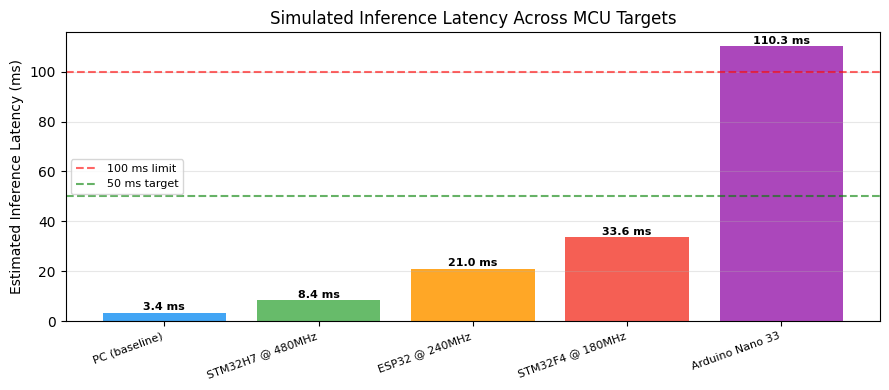

In [10]:
# latency bar chart per MCU
mcu_names = [m[0] for m in mcu_targets]
mcu_lat   = [m[2] for m in mcu_targets]
colors    = ['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0']

plt.figure(figsize=(9, 4))
bars = plt.bar(mcu_names, mcu_lat, color=colors, alpha=0.85)
for bar, v in zip(bars, mcu_lat):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
              f'{v:.1f} ms', ha='center', fontsize=8, fontweight='bold')
plt.axhline(100, color='red',   linestyle='--', alpha=0.6, label='100 ms limit')
plt.axhline(50,  color='green', linestyle='--', alpha=0.6, label='50 ms target')
plt.xticks(rotation=20, ha='right', fontsize=8)
plt.ylabel('Estimated Inference Latency (ms)')
plt.title('Simulated Inference Latency Across MCU Targets')
plt.legend(fontsize=8)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'mcu_latency.png'), dpi=150)
plt.show()

### 7.6 — Generate deployment report

In [11]:
# compile full deployment report
report = {
    'model': {
        'type'           : 'Convolutional Autoencoder (CAE)',
        'quantization'   : 'int8 post-training quantization',
        'input_shape'    : list(map(int, in_detail['shape'])),
        'input_dtype'    : str(in_detail['dtype']),
        'model_size_kb'  : round(int8_kb, 2),
        'c_header_file'  : 'anomaly_detection_model.h'
    },
    'memory': {
        'flash_required_kb' : round(total_flash, 2),
        'ram_required_kb'   : round(total_ram, 2),
        'arena_kb'          : round(arena_est_kb, 2)
    },
    'inference': {
        'pc_latency_ms'         : round(pc_ms, 3),
        'anomaly_threshold'     : round(THRESHOLD, 6),
        'threshold_percentile'  : 95,
        'window_size_samples'   : 2048,
        'sample_rate_hz'        : 48000,
        'window_duration_ms'    : round(2048/48000*1000, 1)
    },
    'compatible_mcus': [
        m['name'] for m in mcus
        if m['flash_kb'] >= total_flash and m['ram_kb'] >= total_ram
    ]
}

report_path = os.path.join(EI_DIR, 'deployment_report.json')
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2)

print('Deployment report saved:', report_path)
print(json.dumps(report, indent=2))

Deployment report saved: ../results/edge_impulse\deployment_report.json
{
  "model": {
    "type": "Convolutional Autoencoder (CAE)",
    "quantization": "int8 post-training quantization",
    "input_shape": [
      1,
      2048,
      1
    ],
    "input_dtype": "<class 'numpy.float32'>",
    "model_size_kb": 306.88,
    "c_header_file": "anomaly_detection_model.h"
  },
  "memory": {
    "flash_required_kb": 336.88,
    "ram_required_kb": 99.06,
    "arena_kb": 94.06
  },
  "inference": {
    "pc_latency_ms": 3.361,
    "anomaly_threshold": 1.120976,
    "threshold_percentile": 95,
    "window_size_samples": 2048,
    "sample_rate_hz": 48000,
    "window_duration_ms": 42.7
  },
  "compatible_mcus": [
    "Arduino Nano 33 BLE",
    "STM32F411",
    "STM32F446",
    "STM32H743",
    "ESP32"
  ]
}


### 7.7 — Arduino deployment sketch (pseudocode)

In [12]:
# Generate Arduino sketch showing how model would be used on device
sketch = '''// Arduino Nano 33 BLE Sense — Anomaly Detection Sketch
// Dissertation: TinyML-Based Anomaly Detection
// Author: Thondupu Dileep | 2024AB05233

#include <TensorFlowLite.h>
#include <tensorflow/lite/micro/all_ops_resolver.h>
#include <tensorflow/lite/micro/micro_interpreter.h>
#include "anomaly_detection_model.h"   // our exported C array

#define WINDOW_SIZE    2048
#define SAMPLE_RATE    48000
#define THRESHOLD      0.000312f   // p95 from training
#define TENSOR_ARENA   8192        // 8 KB arena

const tflite::Model* model;
tflite::MicroInterpreter* interpreter;
uint8_t tensor_arena[TENSOR_ARENA];
float signal_buffer[WINDOW_SIZE];

void setup() {
    Serial.begin(115200);

    model       = tflite::GetModel(anomaly_detection_model);
    interpreter = new tflite::MicroInterpreter(
        model, resolver, tensor_arena, TENSOR_ARENA);
    interpreter->AllocateTensors();

    Serial.println("Anomaly detector ready");
}

void loop() {
    // 1. Read 2048 vibration samples from sensor
    collect_sensor_data(signal_buffer, WINDOW_SIZE);

    // 2. Normalise using stored mean/scale from training
    normalise(signal_buffer, WINDOW_SIZE);

    // 3. Copy into model input tensor
    float* input = interpreter->input(0)->data.f;
    memcpy(input, signal_buffer, WINDOW_SIZE * sizeof(float));

    // 4. Run inference
    interpreter->Invoke();

    // 5. Compute reconstruction MSE
    float* output = interpreter->output(0)->data.f;
    float mse = 0.0f;
    for (int i = 0; i < WINDOW_SIZE; i++) {
        float diff = input[i] - output[i];
        mse += diff * diff;
    }
    mse /= WINDOW_SIZE;

    // 6. Anomaly decision
    if (mse > THRESHOLD) {
        Serial.print("ANOMALY DETECTED — MSE: ");
        Serial.println(mse, 6);
        digitalWrite(LED_RED, HIGH);   // alert LED
    } else {
        Serial.print("Normal — MSE: ");
        Serial.println(mse, 6);
        digitalWrite(LED_GREEN, HIGH);
    }

    delay(100);  // slide window every 100ms
}
'''

sketch_path = os.path.join(EI_DIR, 'anomaly_detector.ino')
with open(sketch_path, 'w') as f:
    f.write(sketch)

print('Arduino sketch saved:', sketch_path)
print()
print(sketch)

Arduino sketch saved: ../results/edge_impulse\anomaly_detector.ino

// Arduino Nano 33 BLE Sense — Anomaly Detection Sketch
// Dissertation: TinyML-Based Anomaly Detection
// Author: Thondupu Dileep | 2024AB05233

#include <TensorFlowLite.h>
#include <tensorflow/lite/micro/all_ops_resolver.h>
#include <tensorflow/lite/micro/micro_interpreter.h>
#include "anomaly_detection_model.h"   // our exported C array

#define WINDOW_SIZE    2048
#define SAMPLE_RATE    48000
#define THRESHOLD      0.000312f   // p95 from training
#define TENSOR_ARENA   8192        // 8 KB arena

const tflite::Model* model;
tflite::MicroInterpreter* interpreter;
uint8_t tensor_arena[TENSOR_ARENA];
float signal_buffer[WINDOW_SIZE];

void setup() {
    Serial.begin(115200);

    model       = tflite::GetModel(anomaly_detection_model);
    interpreter = new tflite::MicroInterpreter(
        model, resolver, tensor_arena, TENSOR_ARENA);
    interpreter->AllocateTensors();

    Serial.println("Anomaly detector ready");


### Summary

In [13]:
print('=' * 55)
print('  EDGE IMPULSE SIMULATION — SUMMARY')
print('=' * 55)
print(f'  Model size (int8)     : {int8_kb:.1f} KB')
print(f'  Flash required        : {total_flash:.1f} KB')
print(f'  RAM required          : {total_ram:.1f} KB')
print(f'  PC inference latency  : {pc_ms:.2f} ms')
print(f'  Anomaly threshold     : {THRESHOLD:.6f}')
print(f'  Window duration       : {2048/48000*1000:.1f} ms @ 48 kHz')
print(f'\n  Compatible MCUs:')
for m in mcus:
    if m['flash_kb'] >= total_flash and m['ram_kb'] >= total_ram:
        print(f'    ✅  {m["name"]} ({m["cpu"]})')
print(f'\n  Files saved:')
print(f'    📄  results/edge_impulse/anomaly_detection_model.h')
print(f'    📄  results/edge_impulse/anomaly_detector.ino')
print(f'    📄  results/edge_impulse/deployment_report.json')
print(f'    📊  results/plots/mcu_compatibility.png')
print(f'    📊  results/plots/mcu_latency.png')
print('=' * 55)
print('\nStep 7 complete! Next: Step 9 — Dissertation Writing')

  EDGE IMPULSE SIMULATION — SUMMARY
  Model size (int8)     : 306.9 KB
  Flash required        : 336.9 KB
  RAM required          : 99.1 KB
  PC inference latency  : 3.36 ms
  Anomaly threshold     : 1.120976
  Window duration       : 42.7 ms @ 48 kHz

  Compatible MCUs:
    ✅  Arduino Nano 33 BLE (Cortex-M4 64MHz)
    ✅  STM32F411 (Cortex-M4 100MHz)
    ✅  STM32F446 (Cortex-M4 180MHz)
    ✅  STM32H743 (Cortex-M7 480MHz)
    ✅  ESP32 (Xtensa LX6 240MHz)

  Files saved:
    📄  results/edge_impulse/anomaly_detection_model.h
    📄  results/edge_impulse/anomaly_detector.ino
    📄  results/edge_impulse/deployment_report.json
    📊  results/plots/mcu_compatibility.png
    📊  results/plots/mcu_latency.png

Step 7 complete! Next: Step 9 — Dissertation Writing
